# TakeMeter — Fine-Tuning Notebook
### Krish A. Patel
### CodePath AI201: Applications of AI Engineering Project 3 (Summer 2026)

This notebook fine-tunes a text classifier on an annotated dataset and comparing it to a zero-shot baseline.

Note: most of the code was already given to me at the start of the project.

---
**Before you run:**
- If you're using Google Colab, make sure you are using a T4 GPU runtime and that you have your Groq API added to Secrets.
- If you're running this notebook locally, make sure your `.env` file is populated with your Groq API key.

Some of the non-essential code is commented to save API calls and/or execution time and make the notebook "Run All"-friendly. Such blocks are marked with `[TODO]`. You may uncomment them as you choose to test out those project components.

In [1]:
import os
import sys

is_colab_env = 'google.colab' in sys.modules
print(f"Running in Google Colab: {is_colab_env}")

Running in Google Colab: False


In [2]:
if is_colab_env:
    # Install any dependencies not pre-installed on Colab
    %pip install -q groq python-dotenv
    print("✅ Dependencies ready")

In [3]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/theca/repos/GitHub/CodePath/AI201/ai201-project3-takemeter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports complete
PyTorch version: 2.12.1+cu130
GPU available: False


---
## Section 1: Load Dataset

Upload the data in CSV format.

In [4]:
# Create label map

LABEL_MAP = {
    "artistic_critique":  0,
    "external_narrative":  1,
    "fandom_expression":  2,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'artistic_critique': 0, 'external_narrative': 1, 'fandom_expression': 2}
Number of labels: 3


In [5]:
if is_colab_env:
    # Upload CSV if in Colab
    from google.colab import files
    print("Select labeled dataset CSV file...")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f"Uploaded: {CSV_PATH}")
else:
    # Assume local path for non-Colab environments
    CSV_PATH = "./data/data.csv"
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(
            f"CSV file not found at {CSV_PATH}. "
            "Please create a 'data' directory and place 'data.csv' inside it, "
            "or update the CSV_PATH variable."
        )
    print(f"Using local CSV file: {CSV_PATH}")

Using local CSV file: ./data/data.csv


In [6]:
# Load and validate dataset
df = pd.read_csv(CSV_PATH)

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['id', 'text', 'author', 'link', 'label', 'annotators', 'notes']
Total examples: 213

Label distribution:
label
artistic_critique     89
external_narrative    84
fandom_expression     40
Name: count, dtype: int64

✅ All labels match LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits the dataset into train / validation / test sets and tokenizes the text.

In [7]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 149 examples
Validation: 32 examples
Test: 32 examples

Train label distribution:
label
artistic_critique     62
external_narrative    59
fandom_expression     28
Name: count, dtype: int64

Test label distribution:
label
artistic_critique     14
external_narrative    12
fandom_expression      6
Name: count, dtype: int64


In [8]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map: 100%|██████████| 32/32 [00:00<00:00, 3807.49 examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune the Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 10 epochs and takes **5-15 minutes** on a T4 GPU.  

In [9]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1370.26it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [11]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────

def train(**kwargs):
    default_training_args = {
        "output_dir": "./takemeter-model",
        "num_train_epochs": 6,         # updated from 3 - give model more training
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_steps": 5,             # updated from 50 - drop this dramatically since dataset is small
        "eval_strategy": "epoch",
        "save_strategy": "epoch",
        "save_total_limit": 1,
        "load_best_model_at_end": True,
        "metric_for_best_model": "accuracy",
        "logging_steps": 5,            # updated from 10 - log more frequently
        "report_to": "none",
    }

    training_args = TrainingArguments(**(default_training_args | kwargs))

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
    trainer.train()
    print("\n✅ Fine-tuning complete")

    return trainer

---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on the locked test set and generates metrics and a confusion matrix.


In [12]:
# Run inference on the test set
def predict(trainer, show_report=False):
    if show_report:
        print("Running inference on test set...")

    def _results(dataset):
        ft_output = trainer.predict(dataset)
        ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
        ft_true_ids = ft_output.label_ids

        ft_probs = torch.nn.functional.softmax(
            torch.tensor(ft_output.predictions), dim=-1
        ).numpy()

        # Overall accuracy
        ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)

        return ft_accuracy, ft_true_ids, ft_pred_ids, ft_probs

    if show_report:
        ft_accuracy, ft_true_ids, ft_pred_ids, ft_probs = _results(test_dataset)
        print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

        # Per-class metrics
        label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
        print("\nPer-class metrics (fine-tuned model):")
        print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

        return ft_accuracy, ft_probs, ft_true_ids, ft_pred_ids, label_names
    else:
        ft_train_accuracy, _, _, _ = _results(train_dataset)
        ft_val_accuracy, _, _, _ = _results(val_dataset)
        ft_test_accuracy, _, _, _ = _results(test_dataset)

        return (ft_train_accuracy, ft_val_accuracy, ft_test_accuracy)

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.070602,1.041882,0.406250
2,0.959525,0.980414,0.531250
3,0.893701,0.927450,0.562500
4,0.710101,0.868140,0.593750
5,0.614541,0.827107,0.656250
6,0.480216,0.798764,0.656250
7,0.525502,0.790157,0.625000
8,0.348281,0.779700,0.718750
9,0.317604,0.782114,0.718750
10,0.282358,0.782113,0.718750


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.05it/s]



✅ Fine-tuning complete
Running inference on test set...



🎯 Fine-tuned model accuracy: 0.781

Per-class metrics (fine-tuned model):
                    precision    recall  f1-score   support

 artistic_critique       0.68      0.93      0.79        14
external_narrative       0.91      0.83      0.87        12
 fandom_expression       1.00      0.33      0.50         6

          accuracy                           0.78        32
         macro avg       0.86      0.70      0.72        32
      weighted avg       0.83      0.78      0.76        32



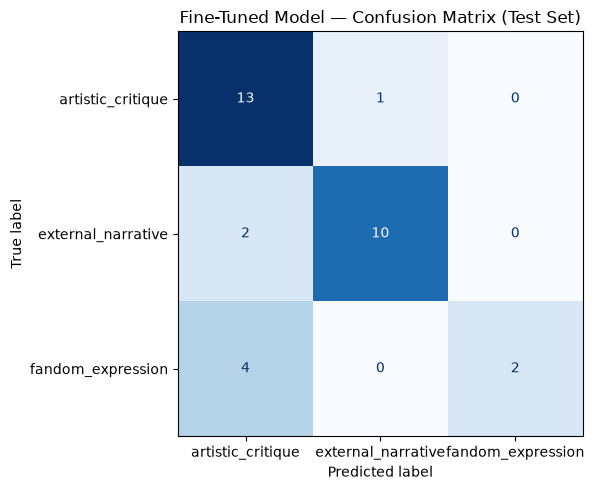

✅ Saved: confusion_matrix.png


In [13]:
trainer = train(
    num_train_epochs=10     # empirically derived in the optional section below
)
ft_accuracy, ft_probs, ft_true_ids, ft_pred_ids, label_names = predict(trainer,show_report=True)

# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png" if is_colab_env else "./results/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png")

In [14]:
# Print wrong predictions for error analysis
wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 7 / 32

--- #1 ---
Text:      I LOVE Delicate. It's soo good😍
True:      fandom_expression
Predicted: artistic_critique  (confidence: 0.49)

--- #2 ---
Text:      "He Said She Said" ~ Taylor on TIWWCHNT

Me: https://youtu.be/4sTHw7HEfHo
True:      artistic_critique
Predicted: external_narrative  (confidence: 0.74)

--- #3 ---
Text:      DANCING WITH OUR HANDS TIED IS A BANGERRRR
True:      fandom_expression
Predicted: artistic_critique  (confidence: 0.59)

--- #4 ---
Text:      In two to three years I would like to see how would we look back at this album.
True:      external_narrative
Predicted: artistic_critique  (confidence: 0.77)

--- #5 ---
Text:      Hey Mama Day
True:      fandom_expression
Predicted: artistic_critique  (confidence: 0.35)

--- #6 ---
Text:      So when's her tour...?
True:      external_narrative
Predicted: artistic_critique  (confidence: 0.50)

--- #7 ---
Text:      NOT Future's verses are better than Taylor's I'm dead
True:      fandom_expre

---
## Optional: Optimal Number of Epochs

Finds the optimal number of training epochs by plotting the train, validation, and test dataset prediction accuracies as a function of the number of epochs used to train the model.

In [15]:
# [TODO] Uncomment to run the experiment
"""
# Find the optimal epoch count
epochs = list(range(2, 21, 2))
accuracies = {
    'train': [],
    'validation': [],
    'test': []
}

for n_epochs in epochs:
    print(f"{n_epochs=}")
    trainer = train(num_train_epochs=n_epochs)
    train_acc, val_acc, test_acc = predict(trainer)
    accuracies['train'].append(train_acc)
    accuracies['validation'].append(val_acc)
    accuracies['test'].append(test_acc)
    print(f'{train_acc=}, {val_acc=}, {test_acc=}')
"""
print()

In [16]:
# [TODO] Uncomment to plot the experiment results
"""
acc_df = pd.DataFrame(accuracies)

plt.plot(epochs, acc_df["train"], label="train")
plt.plot(epochs, acc_df["validation"], label="validation")
plt.plot(epochs, acc_df["test"], label="test")
plt.title("Train, Validation, and Test Accuracy vs Epochs")
plt.xticks(epochs)
plt.xlabel("Number of Training Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("acc_vs_epochs_graph.png" if is_colab_env else "./results/acc_vs_epochs_graph.png", dpi=150)
plt.show()
"""
print()

---
## Section 5: Baseline Classifier (Groq)

Runs the zero-shot baseline using `llama-3.3-70b-versatile`.

In [17]:
from groq import Groq
import dotenv

if is_colab_env:
    # Use Colab Secrets so your key is never visible in the notebook.
    #   1. Click the 🔑 icon in the left sidebar ("Secrets")
    #   2. Add a secret named GROQ_API_KEY with your key as the value
    #   3. Enable notebook access for the secret
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
else:
    # Load from environment variables or .env file for local development
    dotenv.load_dotenv() # Load environment variables from .env file
    GROQ_API_KEY = os.getenv("GROQ_API_KEY")

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (🔑, left "
    "sidebar) or set it as an environment variable (e.g., in a .env file) for local execution."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [18]:
# ── Classification system prompt ────────────────────────────────
# The prompt:
#   1. Names your community and task
#   2. Defines each label in plain language (copy from your planning.md)
#   3. Gives one example post per label
#   4. Tells the model to output ONLY the label name — nothing else
#
# The model's response must match one of the label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """
You are classifying posts from Taylor Swift's reputation album release Reddit megathread.
Assign each post to exactly one of the following categories.

artistic_critique: Primarily contains analysis of the artwork itself and artistic choices (e.g., sound, composition, melody, rhythm, lyrics, genre, production, album song order, artistic evolution, comparisons with other artistic works, etc). Also includes emotions and opinions expressed because of the artwork and artistic choices. Tone must be mostly matter-of-fact with minimal to no joking, slang, caps, etc.
Example: "Wow this album is not good. I was hoping for something in the vein of 1989 and this is... not."

external_narrative: Primarily contains stories or discussion about the broader context (e.g. current events, gossip, celebrity feuds/drama, Billboard charts, sales, reviews, etc.). Includes personal context too, such as discussion about people and situations around the post publisher (e.g. mentions of family, friends, roommates; decisions to buy the album; etc.). Tone must be mostly matter-of-fact with minimal to no joking, slang, caps, etc.
Example: "Just got my Target magazine exclusive version in the mail! Can't wait to hear Reputation. Interested in hearing where Taylor is after 1989 and the whole Kanye debacle."

fandom_expression: Primarily contains standalone emotional assertions, visceral reactions, or pure exclamations without much logic or elaboration (e.g., hype, witty remark, meta-joke, exaggeration, etc.). Sometimes can mix in artwork opinions and current event mentions, but is often distinguishable by a strong use of slang, all caps, emojis, etc.
Example: "I LIVED AND DIED WAITING FOR THIS ALBUM UP UNTIL NOW BUT MY SNAKE QUEEN HAS RESURRECTED ME AND I AM HERE TO PRAY"

To resolve ambiguous cases, follow these guidelines in order:

1. Don't look at content alone - check the tone too. An overly informal tone with a heavy use of slang, caps, etc. is a strong case for `fandom_expression`.
2. Choose the label that represents the at least 2/3 of the post's content. When using this criterion, there should be a clear winner.
3. If there's roughly an equal distribution of post content that can match multiple labels, and the decision is between `artistic_critique` and `external_narrative`, choose the label that forms the main idea or conclusion reached in the post. For example, if celebrity feuds are cited as the reason for a song's beat, then `artistic_critique` takes precedence. Additionally quoted content should not be used as the basis for classification. For example, if someone talks about reviews and pastes a long quote from a review site, the post is still `external_narrative` even if most of the post content may now technically be feedback-oriented due to the excerpt.
4. If there is no clear main idea or conclusion in the post, or if one of the label candidates is `fandom_expression`, use this strict prioritization: `artistic_critique` takes priority over `external_narrative`, which takes priority over `fandom_expression`.

Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
artistic_critique
external_narrative
fandom_expression
"""
print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 3187 characters


In [19]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        print(raw)
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None

In [ ]:
SKIP_FLAG = []

def run_baseline():
    # Run baseline on test set
    print(f"Running baseline on {len(test_df)} examples...")
    print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

    # avoid IDs of text already used in the system prompt to avoid leakage
    AVOID_IDS = set([27, 165, 172])

    baseline_preds = []
    for i, (_, row) in enumerate(test_df.iterrows()):
        if row["id"] in AVOID_IDS:
            print(f"id={row["id"]} encountered - skipping...")
            baseline_preds.append(SKIP_FLAG)
            continue

        pred = classify_with_groq(row["text"])
        baseline_preds.append(pred)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(test_df)} complete...")
        time.sleep(0.1)

    return baseline_preds

def evaluate_baseline(baseline_preds):
    none_count = baseline_preds.count(None)
    if none_count > 0:
        print(f"\n⚠️  {none_count} responses could not be parsed.")
        print("Review the prompt — the model may not be outputting clean label names.")

    # Baseline metrics (exclude unparseable responses)
    valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
            if p is not None and p is not SKIP_FLAG]
    bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
    bl_true_ids = [t for _, t in valid]

    bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
    print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
        f"(evaluated on {len(valid)}/{len(test_df)} parseable/non-skipped responses)")
    print()
    label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
    print("Per-class metrics (baseline):")
    print(classification_report(bl_true_ids, bl_pred_ids, labels=sorted(LABEL_MAP.values()), target_names=label_names, zero_division=0))

    return bl_accuracy

In [ ]:
# [TODO] Uncomment the line below to run and evaluate the baseline test (be careful of hitting Groq's API limit)
# bl_preds = run_baseline()
# bl_acc = evaluate_baseline(bl_preds)

Running baseline on 32 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

🎯 Baseline accuracy: 0.000  (evaluated on 1/32 parseable/non-skipped responses)

Per-class metrics (baseline):
                    precision    recall  f1-score   support

 artistic_critique       0.00      0.00      0.00       0.0
external_narrative       0.00      0.00      0.00       1.0
 fandom_expression       0.00      0.00      0.00       0.0

          accuracy                           0.00       1.0
         macro avg       0.00      0.00      0.00       1.0
      weighted avg       0.00      0.00      0.00       1.0



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.

In [22]:
def compare(bl_accuracy):
    print("=" * 50)
    print("RESULTS COMPARISON")
    print("=" * 50)
    print(f"{'Model':<35} {'Accuracy':>8}")
    print("-" * 45)
    print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
    print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
    print("-" * 45)
    delta = ft_accuracy - bl_accuracy
    direction = "improvement" if delta >= 0 else "regression"
    print(f"\nFine-tuning {direction}: {abs(delta):.3f}")

In [23]:
def export_results(bl_accuracy):
    results = {
        "baseline_accuracy": round(bl_accuracy, 4),
        "finetuned_accuracy": round(ft_accuracy, 4),
        "improvement": round(ft_accuracy - bl_accuracy, 4),
        "test_set_size": len(test_df),
        "label_map": LABEL_MAP,
        "model": MODEL_NAME,
    }
    with open("evaluation_results.json" if is_colab_env else "./results/evaluation_results.json", "w") as f:
        json.dump(results, f, indent=2)

    print("✅ Files ready to download:")
    print("   evaluation_results.json")
    print("   confusion_matrix.png")

In [24]:
# [TODO] Uncomment the line below to run the comparison and export the results (make sure to have run Section 5 first)
# compare(bl_acc)
# export_results(bl_acc)

# Section 7: Run Sample Classifications

In [25]:
def classify_with_finetuned_model(text):
    """Classify a single post using the fine-tuned DistilBERT model."""
    # Tokenize the input text
    inputs = tokenizer(text, truncation=True, max_length=256, return_tensors="pt")

    # Move inputs to the same device as the model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Make prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predicted label ID and all probabilities
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1)

    predicted_id = torch.argmax(probabilities, dim=-1).item()

    # Return predicted ID and all probabilities as a list
    return predicted_id, probabilities[0].tolist()

print("✅ `classify_with_finetuned_model` function created.")

✅ `classify_with_finetuned_model` function created.


In [26]:
df = pd.read_csv(CSV_PATH)
sample = df.sample(n=5, random_state=42) # Added random_state for reproducibility

print("\nSample Classifications (Fine-Tuned DistilBERT):")
print("------------------------------------------")
for idx, row in sample.iterrows():
    id = row["id"]
    text = row["text"]
    true_label = row["label"]
    predicted_id, all_confidences = classify_with_finetuned_model(text)
    predicted_label = ID_TO_LABEL[predicted_id]

    # Format all confidences as a comma-separated string
    confidences_str = ', '.join([f'{c:.2f}' for c in all_confidences])

    print(f"\nID: {id}")
    print(f"Text: {text[:150]}{'...' if len(text) > 150 else ''}")
    print(f"  True Label:      {true_label}")
    print(f"  Predicted Label: {predicted_label} {"✅" if true_label == predicted_label else "❌"}  (confidences: {confidences_str})")


Sample Classifications (Fine-Tuned DistilBERT):
------------------------------------------

ID: 10
Text: The old Popheads can’t come to the phone right now. Why?

BECAUSE THEYRE LIVING
  True Label:      fandom_expression
  Predicted Label: artistic_critique ❌  (confidences: 0.37, 0.28, 0.34)

ID: 198
Text: "my mistakes have been used against me" girl what? oh ffs
  True Label:      external_narrative
  Predicted Label: external_narrative ✅  (confidences: 0.10, 0.76, 0.13)

ID: 67
Text: Props to Taylor and her producers to always knowing which song to copy from. Without You by Lana for Wildest Dreams and now Never Be Like You by Flume...
  True Label:      artistic_critique
  Predicted Label: artistic_critique ✅  (confidences: 0.90, 0.06, 0.04)

ID: 192
Text: a shop in Tokyo, going all the way and being extra, i love it

https://pp.userapi.com/c834102/v834102347/1b23e/5X73WL3CvCA.jpg

https://pp.userapi.com...
  True Label:      external_narrative
  Predicted Label: external_narrative